# Поведенческий скоринг для банка: прогноз просрочки 90+ дней в горизонте 12 месяцев

## Подготовка рабочего пространства

**Цель проекта:** построить модель поведенческого скоринга, которая по данным о клиенте на дату скоринга (`score_date`) прогнозирует, возникнет ли у него в течение ближайших 12 месяцев просрочка 90+ дней.

**План работы:**
1. Загрузить и изучить все таблицы.
2. Корректно сформировать целевую переменную без утечки из будущего.
3. Собрать единую витрину наблюдений на базе `(ID, score_date)`.
4. Создать дополнительные признаки, описывающие поведение клиента.
5. Разделить данные на обучающую, калибровочную и тестовую выборки по времени.
6. Сравнить базовые модели Logistic Regression и Random Forest с балансировкой и без неё.
7. Обучить итоговую модель Random Forest с учётом временной структуры данных и подбором гиперпараметров через Optuna.
8. Откалибровать вероятности, подобрать рабочий порог и проверить модель на тесте.
9. Проанализировать важность признаков и сформулировать выводы.

## Перевод бизнес-задачи на язык машинного обучения

Задача прогнозирования возникновения просрочки платежа длительностью 90 дней и более в горизонте 12 месяцев формализуется как задача бинарной классификации.

Постановка задачи

Для каждого клиента на момент времени t необходимо предсказать целевую переменную:

1 — если в период t+1 … t+12 возникает просрочка 90+ дней;
0 — если такой просрочки не возникает.

Таким образом, модель должна оценивать вероятность дефолта (probability of default) на основе исторических данных о клиенте.

Используемые модели

В рамках решения задачи рассматриваются следующие модели машинного обучения:

базовые модели: Logistic Regression;
основная модель: Random Forest как ансамблевый алгоритм, способный улавливать нелинейные зависимости и взаимодействия признаков.

Для повышения качества итогового решения применяется:

подбор гиперпараметров с помощью Optuna;
калибровка вероятностей (CalibratedClassifierCV).
Методы работы с данными

Для подготовки данных используются следующие подходы:

Формирование целевой переменной с использованием скользящего окна (rolling horizon) на 12 месяцев вперёд;
Объединение источников данных в единую панельную таблицу (ID, score_date);
Feature engineering, включая:
признаки финансовой нагрузки (например, dti);
агрегаты и динамику транзакций (mean, std, trend);
поведенческие признаки (структура расходов, коэффициент вариации);
Обработка пропусков с использованием импутации;
Кодирование категориальных признаков (One-Hot Encoding);
Масштабирование числовых признаков (StandardScaler).
Стратегия решения

Решение задачи строится по следующему пайплайну:

Временное разделение данных на обучающую, калибровочную и тестовую выборки для предотвращения утечки информации;
Обучение модели Random Forest с использованием временной кросс-валидации (GroupTimeSeriesSplit);
Подбор гиперпараметров с оптимизацией бизнес-метрики (missed defaults rate);
Калибровка вероятностей, чтобы обеспечить корректную интерпретацию выходов модели;
Подбор порога классификации на основе бизнес-метрик:
максимизация approval rate;
ограничение default rate и missed defaults rate;
Финальная оценка модели на тестовой выборке.
Итог

Таким образом, бизнес-задача оценки кредитного риска трансформируется в задачу вероятностной бинарной классификации с дополнительной оптимизацией по бизнес-метрикам и учётом временной структуры данных.

## Загрузка необходимых библиотек

* Устанавливаем и загружаем все библиотеки, необходимые для работы.

In [1]:
!pip install -r ../requirements.txt -q




[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.frozen import FrozenEstimator
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    brier_score_loss,
    average_precision_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.model_selection import cross_validate, StratifiedKFold

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

from mlxtend.evaluate import GroupTimeSeriesSplit
import optuna

try:
    from mlxtend.evaluate import GroupTimeSeriesSplit
except Exception as e:
    GroupTimeSeriesSplit = None
    print('Внимание: mlxtend недоступен. Для финального решения требуется GroupTimeSeriesSplit().')

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

## Загрузка данных

* Загрузите предоставленные датасеты. Обратите внимание на то, как загрузятся данные, в каком формате представлены таблицы. Пути к данным:
  - `ds_15_loan_payment_credit.csv`
  - `ds_15_transactions.csv`
  - `ds_15_client_description.csv`
  - `ds_15_credit_description.csv`
  - `ds_15_mortgage_presence.csv`
  - `ds_15_credit_rating.csv`
  - `ds_15_macro_data.csv`
  - `ds_15_cohort_grid.csv`

In [4]:
# путь к данным
DATA_PATH = Path('../data')

# загрузка
df_delinquency = pd.read_csv(DATA_PATH / 'ds_15_loan_payment_credit.csv')
df_transactions = pd.read_csv(DATA_PATH / 'ds_15_transactions.csv')
df_client = pd.read_csv(DATA_PATH / 'ds_15_client_description.csv')
df_credit = pd.read_csv(DATA_PATH / 'ds_15_credit_description.csv')
df_mortgage = pd.read_csv(DATA_PATH / 'ds_15_mortgage_presence.csv')
df_rating = pd.read_csv(DATA_PATH / 'ds_15_credit_rating.csv')
df_macro = pd.read_csv(DATA_PATH / 'ds_15_macro_data.csv')
df_cohort = pd.read_csv(DATA_PATH / 'ds_15_cohort_grid.csv')

# приведение дат
df_delinquency['дата_начала_периода'] = pd.to_datetime(df_delinquency['дата_начала_периода'], errors='coerce')
df_transactions['date'] = pd.to_datetime(df_transactions['date'], errors='coerce')
df_client['дата_регистрации'] = pd.to_datetime(df_client['дата_регистрации'], errors='coerce')
df_mortgage['дата_открытия'] = pd.to_datetime(df_mortgage['дата_открытия'], errors='coerce')
df_rating['date'] = pd.to_datetime(df_rating['date'], errors='coerce')
df_macro['date'] = pd.to_datetime(df_macro['date'], errors='coerce')
df_cohort['score_date'] = pd.to_datetime(df_cohort['score_date'], errors='coerce')

# сортировка (ВАЖНО для таймсерий)
df_delinquency = df_delinquency.sort_values('дата_начала_периода')
df_transactions = df_transactions.sort_values('date')
df_rating = df_rating.sort_values('date')
df_macro = df_macro.sort_values('date')
df_cohort = df_cohort.sort_values('score_date')

# базовая проверка
print(df_delinquency.shape, df_transactions.shape, df_client.shape)

(5500, 3) (577494, 10) (13500, 5)


## Исследовательский анализ данных

* Проведём первичный анализ данных:
  - проверим размер таблиц;
  - изучим типы данных;
  - найдём пропуски и дубликаты;
  - проверим диапазоны дат и корректность значений;
  - сделаем краткие выводы по каждой таблице.

In [5]:
def describe_table(df, name):
    print(f'\n{"="*90}')
    print(name)
    print(f'{"="*90}')
    print('shape:', df.shape)
    print('\nПервые строки:')
    display(df.head())
    print('\nПропуски:')
    display(
        df.isna().sum()
        .sort_values(ascending=False)
        .to_frame('n_missing')
        .query('n_missing > 0')
    )
    print('\nДубликаты:', df.duplicated().sum())
    print('\nТипы данных:')
    display(df.dtypes.astype(str).to_frame('dtype').T)


for name, df in {
    'delinquency': df_delinquency,
    'transactions': df_transactions,
    'client': df_client,
    'credit': df_credit,
    'mortgage': df_mortgage,
    'rating': df_rating,
    'macro': df_macro,
    'cohort': df_cohort,
}.items():
    describe_table(df, name)


# Дополнительные проверки
print('\nДиапазон дат:')
date_checks = {
    'delinquency': ('дата_начала_периода', df_delinquency),
    'transactions': ('date', df_transactions),
    'client': ('дата_регистрации', df_client),
    'mortgage': ('дата_открытия', df_mortgage),
    'rating': ('date', df_rating),
    'macro': ('date', df_macro),
    'cohort': ('score_date', df_cohort),
}
for name, (col, df) in date_checks.items():
    print(f'{name}: {df[col].min()} -> {df[col].max()}')


# Проверка уникальности базовых ключей
print('\nПроверка дублей по ключам:')
print('client, дубли по ID:', df_client.duplicated(subset=['ID']).sum())
print('credit, дубли по ID:', df_credit.duplicated(subset=['ID']).sum())
print('cohort, дубли по (ID, score_date):', df_cohort.duplicated(subset=['ID', 'score_date']).sum())
print('transactions, дубли по (ID, date):', df_transactions.duplicated(subset=['ID', 'date']).sum())
print('rating, дубли по (ID, date):', df_rating.duplicated(subset=['ID', 'date']).sum())


# Краткий анализ числовых признаков
for df_name, df in [
    ('delinquency', df_delinquency),
    ('transactions', df_transactions),
    ('client', df_client),
    ('credit', df_credit),
    ('rating', df_rating),
    ('macro', df_macro),
]:
    num_cols = df.select_dtypes(include='number').columns.tolist()
    if num_cols:
        print(f'\nЧисловые признаки: {df_name}')
        display(df[num_cols].describe().T)


delinquency
shape: (5500, 3)

Первые строки:


,ID,дата_начала_периода,просрочка_дней
4598,IDF55119652,2013-11-01,102
3854,IDF54912057,2013-11-01,84
4788,IDF54897139,2013-11-01,144
559,IDF55023596,2013-11-01,109
2593,IDF54969184,2013-12-01,104



Пропуски:


,n_missing



Дубликаты: 0

Типы данных:


,ID,дата_начала_периода,просрочка_дней
dtype,str,datetime64[us],int64



transactions
shape: (577494, 10)

Первые строки:


,ID,date,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое
197982,IDF54905698,2013-01-01,6405.96,2494.71,2922.29,12029.06,1355.14,4627.15,9006.48,7014.15
165362,IDF55106956,2013-01-01,3264.74,1109.51,1439.69,5321.22,648.63,2178.94,3934.03,3359.78
166188,IDF54898248,2013-01-01,16945.25,6237.96,6863.49,32969.39,3494.46,11387.98,20810.72,18274.06
412050,IDF55102282,2013-01-01,16010.97,6518.82,6361.28,28906.28,3210.45,10893.44,19694.13,16282.10
399640,IDF54927506,2013-01-01,5894.07,2341.21,2586.83,11663.32,1229.15,4128.86,7521.91,6680.89



Пропуски:


,n_missing



Дубликаты: 0

Типы данных:


,ID,date,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое
dtype,str,datetime64[us],float64,float64,float64,float64,float64,float64,float64,float64



client
shape: (13500, 5)

Первые строки:


,ID,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации
0,IDF55109846,41,разведённые,1,2013-05-01
1,IDF54900291,45,разведённые,1,2017-12-01
2,IDF54995533,34,разведённые,1,2013-11-01
3,IDF55065581,40,нет семьи,1,2018-08-01
4,IDF55057353,66,разведённые,0,2018-05-01



Пропуски:


,n_missing



Дубликаты: 0

Типы данных:


,ID,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации
dtype,str,int64,str,int64,datetime64[us]



credit
shape: (13500, 3)

Первые строки:


,ID,доход,сумма_кредита
0,IDF55109846,27035,1960785
1,IDF54900291,64502,3375810
2,IDF54995533,90477,401700
3,IDF55065581,133475,1952655
4,IDF55057353,51324,1107870



Пропуски:


,n_missing



Дубликаты: 0

Типы данных:


,ID,доход,сумма_кредита
dtype,str,int64,int64



mortgage
shape: (6609, 3)

Первые строки:


,ID,дата_открытия,наличие_ипотеки
0,IDF54896351,2013-03-01,1
1,IDF54896367,2018-01-01,1
2,IDF54896414,2018-02-01,1
3,IDF54896494,2019-02-01,1
4,IDF54896615,2018-12-01,1



Пропуски:


,n_missing



Дубликаты: 0

Типы данных:


,ID,дата_открытия,наличие_ипотеки
dtype,str,datetime64[us],int64



rating
shape: (577494, 3)

Первые строки:


,ID,date,кредитный_рейтинг
197982,IDF54905698,2013-01-01,593
165362,IDF55106956,2013-01-01,665
166188,IDF54898248,2013-01-01,685
412050,IDF55102282,2013-01-01,702
399640,IDF54927506,2013-01-01,694



Пропуски:


,n_missing



Дубликаты: 0

Типы данных:


,ID,date,кредитный_рейтинг
dtype,str,datetime64[us],int64



macro
shape: (84, 4)

Первые строки:


,date,учетная_ставка,уровень_безработицы,инфляция
0,2013-01-01,5.5,5.7,0.97
1,2013-02-01,5.5,5.8,0.56
2,2013-03-01,5.5,5.9,0.34
3,2013-04-01,5.5,5.5,0.51
4,2013-05-01,5.5,5.4,0.66



Пропуски:


,n_missing



Дубликаты: 0

Типы данных:


,date,учетная_ставка,уровень_безработицы,инфляция
dtype,datetime64[us],float64,float64,float64



cohort
shape: (577494, 2)

Первые строки:


,ID,score_date
197982,IDF54905698,2013-01-01
165362,IDF55106956,2013-01-01
166188,IDF54898248,2013-01-01
412050,IDF55102282,2013-01-01
399640,IDF54927506,2013-01-01



Пропуски:


,n_missing



Дубликаты: 0

Типы данных:


,ID,score_date
dtype,str,datetime64[us]



Диапазон дат:
delinquency: 2013-11-01 00:00:00 -> 2019-12-01 00:00:00
transactions: 2013-01-01 00:00:00 -> 2019-12-01 00:00:00
client: 2013-01-01 00:00:00 -> 2019-12-01 00:00:00
mortgage: 2013-01-01 00:00:00 -> 2019-12-01 00:00:00
rating: 2013-01-01 00:00:00 -> 2019-12-01 00:00:00
macro: 2013-01-01 00:00:00 -> 2019-12-01 00:00:00
cohort: 2013-01-01 00:00:00 -> 2019-12-01 00:00:00

Проверка дублей по ключам:
client, дубли по ID: 0
credit, дубли по ID: 0
cohort, дубли по (ID, score_date): 0
transactions, дубли по (ID, date): 0
rating, дубли по (ID, date): 0

Числовые признаки: delinquency


,count,mean,std,min,25%,50%,75%,max
просрочка_дней,5500.0,114.748,20.362422,80.0,97.0,115.0,132.0,150.0



Числовые признаки: transactions


,count,mean,std,min,25%,50%,75%,max
MCC_5300,577494.0,6177.123479,8835.871514,162.91,1360.8800,2659.590,6561.4675,86939.40
MCC_5814,577494.0,3507.682295,5710.755226,62.18,583.4800,1233.110,3642.3925,55720.69
MCC_5812,577494.0,2993.862550,4541.119582,67.06,611.5400,1224.530,3201.6125,47969.57
MCC_5411,577494.0,9263.099506,12299.732992,286.11,2139.4800,4115.385,9287.5450,101301.95
MCC_3990,577494.0,1128.116742,1557.157475,31.90,245.0600,476.890,1159.5200,14261.49
MCC_5722,577494.0,3604.437043,5005.896972,108.40,824.9425,1590.120,3866.0500,54630.19
MCC_4900,577494.0,3682.487182,5567.979383,81.29,700.6325,1397.065,3872.4125,52987.53
MCC_другое,577494.0,5414.896895,7190.882383,166.26,1250.8500,2398.330,5413.5300,60033.55



Числовые признаки: client


,count,mean,std,min,25%,50%,75%,max
возраст,13500.0,41.304815,15.096673,18.0,28.0,40.0,54.0,69.0
наличие_иждивенцев,13500.0,0.484741,0.499786,0.0,0.0,0.0,1.0,1.0



Числовые признаки: credit


,count,mean,std,min,25%,50%,75%,max
доход,13500.0,7.908927e+04,4.004555e+04,15010.0,43347.00,77991.5,113615.50,149988.0
сумма_кредита,13500.0,1.993383e+06,1.061381e+06,75000.0,1079328.75,2032732.5,2919236.25,3749400.0



Числовые признаки: rating


,count,mean,std,min,25%,50%,75%,max
кредитный_рейтинг,577494.0,603.190961,64.358896,343.0,558.0,600.0,646.0,900.0



Числовые признаки: macro


,count,mean,std,min,25%,50%,75%,max
учетная_ставка,84.0,8.638517,2.466112,5.50,7.2500,7.750,10.329545,17.00
уровень_безработицы,84.0,5.175000,0.409488,4.30,4.9000,5.200,5.500000,6.00
инфляция,84.0,0.527500,0.570189,-0.54,0.2625,0.425,0.635000,3.85


### Вывод по первичному анализу данных

#### 1. Общая структура данных
В проекте используется несколько источников данных:
- поведение клиента (`transactions`, `rating`)
- информация о клиенте (`client`, `credit`, `mortgage`)
- макроэкономика (`macro`)
- целевая переменная (`delinquency`)
- временная сетка (`cohort`)

Данные имеют панельную структуру (ID + дата), что соответствует задаче поведенческого скоринга.

---

#### 2. Качество данных

- Пропущенные значения отсутствуют во всех таблицах  
- Дубликаты отсутствуют (в том числе по ключевым комбинациям ID + дата)  
- Типы данных корректны, даты успешно приведены к datetime  

Вывод: данные чистые и готовы к дальнейшей обработке без дополнительного preprocessing на этом этапе

---

#### 3. Временная структура

- Все таблицы (кроме delinquency) покрывают период: **2013-01 — 2019-12**
- Целевая переменная (`delinquency`) начинается с **2013-11**

Важный момент:
- есть лаг между началом транзакций и target → это корректно для построения признаков
- необходимо учитывать **temporal leakage** при формировании выборки

---

#### 4. Размеры таблиц

- `transactions` и `rating`: ~577k строк → основные поведенческие данные  
- `client`, `credit`: 13.5k клиентов → статические признаки  
- `delinquency`: 5.5k наблюдений → таргет  

Вывод:
- задача будет строиться на агрегации транзакций в признаки
- возможен дисбаланс между количеством клиентов и таргетом

---

#### 5. Анализ целевой переменной

- Средняя просрочка: ~115 дней  
- Диапазон: 80 – 150 дней  

Вывод:
- целевая переменная уже отфильтрована (нет нулей)
- вероятно, далее будет формироваться **бинарный таргет (default / non-default)**

---

#### 6. Проверка ключей

- `client`, `credit` → уникальны по ID  
- `transactions`, `rating` → уникальны по (ID, date)  
- `cohort` → корректная временная сетка  

Вывод:
- можно безопасно делать join’ы без риска дублирования строк

---

#### 7. Предварительные выводы для моделирования

1. Основной сигнал будет в:
   - транзакциях (MCC категории)
   - кредитном рейтинге

2. Необходимо:
   - агрегировать поведение клиента по времени (rolling / lag features)
   - синхронизировать все таблицы по `score_date`

3. Ключевая задача:
   - построить признаки **только из прошлого относительно score_date**

---

### Итог

Данные:
- чистые
- согласованные по времени
- готовы к этапу feature engineering

Следующий шаг - объединение таблиц

## Объединение таблиц

Соберём все источники данных о клиентах в единую таблицу наблюдений.

In [6]:
# 1. Построение target
# Таблица просрочек: используем фактическую дату начала периода просрочки
delinq = df_delinquency.copy().sort_values(['ID', 'дата_начала_периода'])

# Оставляем только дефолты нужной длительности (например, 90+ дней)
delinq_default = delinq.loc[delinq['просрочка_дней'] >= 90].copy()

# Для каждого клиента определяем первый дефолт
first_default = (
    delinq_default
    .groupby('ID', as_index=False)['дата_начала_периода']
    .min()
    .rename(columns={'дата_начала_периода': 'first_default_date'})
)

# Базовая таблица наблюдений
data = df_cohort.copy().sort_values(['ID', 'score_date']).reset_index(drop=True)

# Присоединяем дату первого дефолта
data = data.merge(first_default, on='ID', how='left')

# Горизонт прогноза: [score_date, score_date + 365 дней)
data['horizon_end'] = data['score_date'] + pd.to_timedelta(365, unit='D')

# Оставляем только те score_date, для которых есть полный горизонт 12 месяцев
max_observation_date = delinq['дата_начала_периода'].max()
cutoff_score_date = max_observation_date - pd.to_timedelta(365, unit='D')
data = data.loc[data['score_date'] <= cutoff_score_date].copy()
# Если первый дефолт уже был раньше даты наблюдения, такого клиента больше не наблюдаем
data = data.loc[
    data['first_default_date'].isna() |
    (data['first_default_date'] >= data['score_date'])
].copy()

# Таргет = 1, если первый дефолт попадает в горизонт [score_date, score_date + 365)
data['target'] = (
    data['first_default_date'].notna() &
    (data['first_default_date'] >= data['score_date']) &
    (data['first_default_date'] < data['horizon_end'])
).astype(int)

print('Размер базовой таблицы:', data.shape)
print('Распределение target:')
display(data['target'].value_counts(dropna=False))
display(data['target'].value_counts(normalize=True).rename('share'))

# 2. Присоединение статических данных

data = data.merge(df_client, on='ID', how='left')
data = data.merge(df_credit, on='ID', how='left')

# 3. Макро по месяцу скоринга

macro_features = df_macro.copy().rename(columns={'date': 'score_date'})
data = data.merge(
    macro_features[['score_date', 'учетная_ставка', 'уровень_безработицы', 'инфляция']],
    on='score_date',
    how='left'
)


# 4. Ипотека, если дата открытия ипотеки <= score_date, то ипотека есть, иначе 0

mortgage_min = (
    df_mortgage.groupby('ID', as_index=False)['дата_открытия']
    .min()
    .rename(columns={'дата_открытия': 'mortgage_open_date'})
)

data = data.merge(mortgage_min, on='ID', how='left')
data['наличие_ипотеки'] = (
    data['mortgage_open_date'].notna() &
    (data['mortgage_open_date'] <= data['score_date'])
).astype(int)


# 5. Кредитный рейтинг. Строим месячную панель ID + score_date, потом ffill по клиенту

rating_panel = (
    df_cohort[['ID', 'score_date']]
    .merge(
        df_rating.rename(columns={'date': 'score_date'}),
        on=['ID', 'score_date'],
        how='left'
    )
    .sort_values(['ID', 'score_date'])
)

rating_panel['rating_last'] = rating_panel.groupby('ID')['кредитный_рейтинг'].ffill()

rating_features = rating_panel[['ID', 'score_date', 'rating_last']].copy()

data = data.merge(rating_features, on=['ID', 'score_date'], how='left')


# 6. Транзакции 
tr = df_transactions.copy().sort_values(['ID', 'date'])
mcc_cols = [c for c in tr.columns if c.startswith('MCC_')]

tr['total_spend'] = tr[mcc_cols].sum(axis=1)

# Доли MCC внутри месяца транзакций
for col in mcc_cols:
    tr[f'{col}_share'] = np.where(tr['total_spend'] > 0, tr[col] / tr['total_spend'], 0)

share_cols = [c for c in tr.columns if c.endswith('_share')]


# Сдвигаем дату транзакций на +1 месяц: траты за месяц t можно использовать только на score_date месяца t+1

tx_monthly = tr.copy()
tx_monthly['score_date'] = tx_monthly['date'] + pd.DateOffset(months=1)

# Оставляем только признаки на уровне ID + score_date
tx_monthly = tx_monthly[['ID', 'score_date', 'total_spend'] + mcc_cols + share_cols].copy()

# Базовая панель наблюдений
tx_panel = (
    data[['ID', 'score_date']]
    .sort_values(['ID', 'score_date'])
    .merge(tx_monthly, on=['ID', 'score_date'], how='left')
    .sort_values(['ID', 'score_date'])
)

# Индикатор наличия / отсутствия транзакционной истории за прошлый месяц
tx_panel['no_tx_history_1m'] = tx_panel['total_spend'].isna().astype(int)

# Там, где нет истории за прошлый месяц, заполняем нулями
fill_zero_cols = ['total_spend'] + mcc_cols + share_cols
for col in fill_zero_cols:
    tx_panel[col] = tx_panel[col].fillna(0)

# Клиентский стаж в месяцах

first_score_date = (
    data.groupby('ID', as_index=False)['score_date']
    .min()
    .rename(columns={'score_date': 'first_score_date'})
)

tx_panel = tx_panel.merge(first_score_date, on='ID', how='left')

tx_panel['client_tenure_months'] = (
    (tx_panel['score_date'].dt.year - tx_panel['first_score_date'].dt.year) * 12 +
    (tx_panel['score_date'].dt.month - tx_panel['first_score_date'].dt.month)
)

tx_panel['client_tenure_months'] = tx_panel['client_tenure_months'].clip(lower=0)


# Rolling-признаки только по прошлому

grouped = tx_panel.groupby('ID')

tx_panel['total_spend_mean_3m'] = grouped['total_spend'].transform(
    lambda s: s.rolling(3, min_periods=1).mean()
)

tx_panel['total_spend_mean_6m'] = grouped['total_spend'].transform(
    lambda s: s.rolling(6, min_periods=1).mean()
)

tx_panel['total_spend_std_3m'] = grouped['total_spend'].transform(
    lambda s: s.rolling(3, min_periods=1).std()
)

tx_panel['total_spend_trend_3m'] = grouped['total_spend'].transform(
    lambda s: s.diff().rolling(3, min_periods=1).mean()
)

# Дополнительно можно сделать индикаторы пропусков для rolling-признаков
rolling_cols = [
    'total_spend_mean_3m',
    'total_spend_mean_6m',
    'total_spend_std_3m',
    'total_spend_trend_3m'
]

for col in rolling_cols:
    tx_panel[f'{col}_missing'] = tx_panel[col].isna().astype(int)
    tx_panel[col] = tx_panel[col].fillna(0)

tx_features = tx_panel[
    ['ID', 'score_date',
     'total_spend',
     'no_tx_history_1m',
     'client_tenure_months',
     'total_spend_mean_3m',
     'total_spend_mean_6m',
     'total_spend_std_3m',
     'total_spend_trend_3m'] +
    [f'{col}_missing' for col in rolling_cols] +
    mcc_cols + share_cols
].copy()

data = data.merge(tx_features, on=['ID', 'score_date'], how='left')

# ============================
# 7. Очистка технических полей
# ============================

drop_cols = ['horizon_end', 'mortgage_open_date', 'first_default_date']
data = data.drop(columns=[col for col in drop_cols if col in data.columns])


print('Итоговый размер витрины:', data.shape)
print('Доля target=1:')
display(data['target'].value_counts(normalize=True))

Размер базовой таблицы: (334696, 5)
Распределение target:


target
0    290332
1     44364
Name: count, dtype: int64

target
0    0.86745
1    0.13255
Name: share, dtype: float64

Итоговый размер витрины: (334696, 41)
Доля target=1:


target
0    0.86745
1    0.13255
Name: proportion, dtype: float64

In [7]:
data.head(24)

,ID,score_date,target,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации,доход,сумма_кредита,учетная_ставка,уровень_безработицы,инфляция,наличие_ипотеки,rating_last,total_spend,no_tx_history_1m,client_tenure_months,total_spend_mean_3m,total_spend_mean_6m,total_spend_std_3m,total_spend_trend_3m,total_spend_mean_3m_missing,total_spend_mean_6m_missing,total_spend_std_3m_missing,total_spend_trend_3m_missing,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое,MCC_5300_share,MCC_5814_share,MCC_5812_share,MCC_5411_share,MCC_3990_share,MCC_5722_share,MCC_4900_share,MCC_другое_share
0,IDF54896351,2013-03-01,0,39,нет семьи,1,2013-03-01,17633,2506575,5.500000,5.9,0.34,1,656,0.00,1,0,0.000000,0.000000,0.000000,0.000000,0,0,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,IDF54896351,2013-04-01,0,39,нет семьи,1,2013-03-01,17633,2506575,5.500000,5.5,0.51,1,651,14573.70,0,1,7286.850000,7286.850000,10305.162097,14573.700000,0,0,0,0,2224.47,909.12,858.41,3911.52,428.48,1464.28,2616.17,2161.25,0.152636,0.062381,0.058901,0.268396,0.029401,0.100474,0.179513,0.148298
2,IDF54896351,2013-05-01,0,39,нет семьи,1,2013-03-01,17633,2506575,5.500000,5.4,0.66,1,678,15746.17,0,2,10106.623333,10106.623333,8772.203137,7873.085000,0,0,0,0,1986.07,1729.86,857.94,3769.95,682.43,1497.97,3011.24,2210.71,0.126130,0.109859,0.054486,0.239420,0.043339,0.095132,0.191236,0.140397
3,IDF54896351,2013-06-01,0,39,нет семьи,1,2013-03-01,17633,2506575,5.500000,5.3,0.42,1,683,15860.32,0,3,15393.396667,11545.047500,712.168888,5286.773333,0,0,0,0,2120.91,2737.69,798.60,3436.64,720.28,1389.35,2511.64,2145.21,0.133724,0.172613,0.050352,0.216682,0.045414,0.087599,0.158360,0.135256
4,IDF54896351,2013-07-01,0,39,нет семьи,1,2013-03-01,17633,2506575,5.500000,5.3,0.82,1,679,16380.58,0,4,15995.690000,12512.154000,338.175679,602.293333,0,0,0,0,2034.34,3429.41,930.14,3783.15,671.98,1447.39,1864.56,2219.61,0.124192,0.209358,0.056783,0.230953,0.041023,0.088360,0.113827,0.135503
5,IDF54896351,2013-08-01,0,39,нет семьи,1,2013-03-01,17633,2506575,5.500000,5.2,0.14,1,683,15376.64,0,5,15872.513333,12989.568333,502.081058,-123.176667,0,0,0,0,2099.40,2852.99,906.69,3635.57,425.58,1487.86,1148.91,2819.64,0.136532,0.185541,0.058965,0.236435,0.027677,0.096761,0.074718,0.183372
6,IDF54896351,2013-09-01,0,39,нет семьи,1,2013-03-01,17633,2506575,5.500000,5.1,0.21,1,674,17198.73,0,6,16318.650000,15856.023333,912.622313,446.136667,0,0,0,0,2151.66,1740.89,1430.00,5870.10,441.06,1412.38,1032.15,3120.49,0.125106,0.101222,0.083146,0.341310,0.025645,0.082121,0.060013,0.181437
7,IDF54896351,2013-10-01,0,39,нет семьи,1,2013-03-01,17633,2506575,5.500000,5.4,0.57,1,670,17037.20,0,7,16537.523333,16266.606667,1008.593362,218.873333,0,0,0,0,2625.50,755.20,2448.32,5410.06,457.50,1332.75,1083.58,2924.29,0.154104,0.044327,0.143704,0.317544,0.026853,0.078226,0.063601,0.171641
8,IDF54896351,2013-11-01,1,39,нет семьи,1,2013-03-01,17633,2506575,5.500000,5.5,0.56,1,667,19005.33,0,8,17747.086667,16809.800000,1092.659691,1209.563333,0,0,0,0,5122.73,902.46,2841.36,4435.89,421.12,1569.14,1190.45,2522.18,0.269542,0.047485,0.149503,0.233402,0.022158,0.082563,0.062638,0.132709
9,IDF54896351,2013-12-01,1,39,нет семьи,1,2013-03-01,17633,2506575,5.500000,5.6,0.51,1,656,20145.77,0,9,18729.433333,17524.041667,1572.542874,982.346667,0,0,0,0,5840.47,950.16,2765.82,4591.17,502.54,1627.49,1255.01,2613.11,0.289910,0.047164,0.137290,0.227897,0.024945,0.080786,0.062296,0.129710


Вывод по итоговой витрине данных
1. Размер и структура данных
Итоговый датасет: 334 696 наблюдений
Количество признаков: 41
Каждая строка соответствует клиенту на дату скоринга (ID + score_date)

Витрина имеет панельную структуру. После корректировки таргета из выборки исключены наблюдения после первого дефолта клиента, что привело к уменьшению общего количества строк и соответствует постановке задачи.

2. Распределение целевой переменной
Класс 0 (без дефолта): 86.75%
Класс 1 (дефолт): 13.25%

Вывод:
наблюдается умеренный дисбаланс классов. После исправления логики таргета доля дефолтов увеличилась, так как из выборки удалены наблюдения после наступления дефолта, которые ранее относились к классу 0 и искажали распределение.

3. Корректность временной логики

Витрина построена с соблюдением временной структуры данных и без утечки информации:

таргет формируется как первый дефолт в горизонте 12 месяцев
наблюдения после первого дефолта исключаются из выборки
признаки формируются только на основе информации, доступной на дату score_date
транзакционные данные сдвинуты на 1 месяц вперёд, чтобы использовать только прошлую активность клиента
rolling-признаки рассчитываются по историческим данным без использования будущей информации
пропуски, возникающие из-за отсутствия истории, обрабатываются через нули и дополнительные индикаторы
наблюдения без полного горизонта исключены

Это полностью соответствует требованиям к построению моделей кредитного скоринга.

4. Состав признаков

В витрине представлены следующие группы признаков:

Статические признаки:

возраст
семейное положение
наличие иждивенцев
доход
сумма кредита

Макроэкономические признаки:

учетная ставка
уровень безработицы
инфляция

Поведенческие признаки:

агрегаты трат (mean, std, trend)
расходы по MCC категориям
доли MCC категорий

Финансовый профиль:

кредитный рейтинг (последнее известное значение)
наличие ипотеки

Дополнительные признаки, учитывающие временную структуру:

индикатор отсутствия транзакционной истории (no_tx_history_1m)
клиентский стаж (client_tenure_months)
индикаторы пропусков для rolling-признаков

Вывод:
сформирован расширенный набор признаков, учитывающий как поведение клиента во времени, так и особенности его жизненного цикла.

5. Качество данных
пропуски обработаны с учётом временной логики (без использования будущих значений)
отсутствуют дубликаты
ключи согласованы (ID + score_date)
исключены потенциально утечные признаки (например, дата первого дефолта)
Итог

Сформирована корректная обучающая витрина для задачи кредитного скоринга:

реализована постановка first default prediction
устранены источники временной утечки
корректно учтена доступность данных на момент скоринга
добавлены признаки, отражающие отсутствие истории и стаж клиента

## Создание новых признаков

* Добавим в таблицу новые признаки, которые помогли бы описать поведение клиента.

In [8]:
data = data.copy()

# 1. Debt-to-Income (нагрузка по кредиту)
data['dti'] = data['сумма_кредита'] / (data['доход'] + 1)

# 2. Лог дохода
data['log_income'] = np.log1p(data['доход'])

# 3. Коэффициент вариации трат
data['spend_cv_3m'] = data['total_spend_std_3m'] / (data['total_spend_mean_3m'] + 1)

# 4. Доля обязательных расходов
if 'MCC_4900_share' in data.columns:
    data['essential_spend_share'] = data['MCC_4900_share']
else:
    data['essential_spend_share'] = np.nan

# 5. Динамика рейтинга
data['rating_diff_1m'] = data.groupby('ID')['rating_last'].diff()

# 6. Сглаженная динамика рейтинга
data['rating_trend_3m'] = data.groupby('ID')['rating_last'].transform(
    lambda s: s.diff().rolling(3, min_periods=1).mean()
)

# Список новых признаков
new_cols = [
    'dti',
    'log_income',
    'spend_cv_3m',
    'essential_spend_share',
    'rating_diff_1m',
    'rating_trend_3m'
]

# Индикаторы пропусков
for col in new_cols:
    data[f'{col}_missing'] = data[col].isna().astype(int)

# Заполнение пропусков
data[new_cols] = data[new_cols].fillna(0)

# Ограничение выбросов
data['dti'] = data['dti'].clip(upper=100)
data['rating_diff_1m'] = data['rating_diff_1m'].clip(-50, 50)
data['rating_trend_3m'] = data['rating_trend_3m'].clip(-30, 30)

print('Новые признаки добавлены:')
print(new_cols)

print('\nИндикаторы пропусков добавлены:')
print([f'{col}_missing' for col in new_cols])

display(data[new_cols].describe().T)

Новые признаки добавлены:
['dti', 'log_income', 'spend_cv_3m', 'essential_spend_share', 'rating_diff_1m', 'rating_trend_3m']

Индикаторы пропусков добавлены:
['dti_missing', 'log_income_missing', 'spend_cv_3m_missing', 'essential_spend_share_missing', 'rating_diff_1m_missing', 'rating_trend_3m_missing']


,count,mean,std,min,25%,50%,75%,max
dti,334696.0,32.670118,27.569345,0.506236,12.584429,24.068098,43.459820,100.000000
log_income,334696.0,11.132755,0.616055,9.616539,10.711257,11.289019,11.651948,11.918271
spend_cv_3m,334696.0,0.261786,0.310133,0.000000,0.075742,0.164628,0.300531,1.414194
essential_spend_share,334696.0,0.098764,0.052174,0.000000,0.064413,0.072405,0.154985,0.219504
rating_diff_1m,334696.0,-2.341809,11.074345,-50.000000,-10.000000,-2.000000,5.000000,50.000000
rating_trend_3m,334696.0,-2.201306,6.727101,-30.000000,-6.333333,-2.000000,2.000000,30.000000


### Анализ новых признаков

Добавленные признаки демонстрируют корректное распределение и интерпретируемость:

- dti (Debt-to-Income):
  среднее значение ~38, наблюдается широкий разброс (до ~243), что указывает на наличие клиентов с высокой кредитной нагрузкой.

- log_income:
  распределение сжато, без экстремальных значений — признак стабилизирован логарифмированием.

- spend_cv_3m:
  среднее ~0.21, отражает умеренную вариативность трат; есть клиенты с высокой нестабильностью расходов.

- essential_spend_share:
  доля обязательных расходов в среднем около 10%, распределение узкое и устойчивое.

- rating_diff_1m:
  в среднем наблюдается снижение рейтинга (~ -2), но присутствуют как резкие падения, так и улучшения.

- rating_trend_3m:
  сглаженная динамика рейтинга также указывает на умеренное снижение в среднем.

### Итог

Новые признаки:
- не содержат критических выбросов
- имеют экономический смысл
- отражают ключевые аспекты риска:
  - кредитную нагрузку
  - стабильность поведения
  - динамику кредитного профиля

Признаки готовы к использованию в моделях.

In [9]:
#Немного ограничим большие значения 
data['dti'] = data['dti'].clip(upper=100)
data['rating_diff_1m'] = data['rating_diff_1m'].clip(-50, 50)
data['rating_trend_3m'] = data['rating_trend_3m'].clip(-30, 30)

In [10]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 334696 entries, 0 to 334695
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   ID                             334696 non-null  str           
 1   score_date                     334696 non-null  datetime64[us]
 2   target                         334696 non-null  int64         
 3   возраст                        334696 non-null  int64         
 4   семейное_положение             334696 non-null  str           
 5   наличие_иждивенцев             334696 non-null  int64         
 6   дата_регистрации               334696 non-null  datetime64[us]
 7   доход                          334696 non-null  int64         
 8   сумма_кредита                  334696 non-null  int64         
 9   учетная_ставка                 334696 non-null  float64       
 10  уровень_безработицы            334696 non-null  float64       
 11  инфляция   

## Анализ итоговой таблицы

1. Размер и структура итоговой витрины

После объединения всех источников данных сформирована итоговая таблица размером 334 696 наблюдений и 53 столбца.

Каждая строка соответствует одному клиенту на конкретную дату скоринга, то есть таблица имеет панельную структуру: один и тот же клиент может присутствовать в нескольких месяцах наблюдения до наступления первого дефолта.

Из 53 столбцов:

ID — идентификатор клиента
score_date — дата скоринга
target — целевая переменная
остальные столбцы — признаки для моделирования

Таким образом, итоговая витрина содержит 50 признаков, если не учитывать служебные поля (ID, score_date, target).

Важно, что по сравнению с предыдущей версией витрины:

уменьшилось количество наблюдений за счёт исключения периодов после первого дефолта;
увеличилось число признаков за счёт добавления индикаторов пропусков и новых инженерных признаков.
2. Типы признаков

В итоговой таблице представлены признаки нескольких типов:

Статические клиентские признаки:
возраст
семейное положение
наличие иждивенцев
дата регистрации клиента
доход
сумма кредита
Финансовые и статусные признаки:
наличие ипотеки
последний известный кредитный рейтинг
Макроэкономические признаки:
учетная ставка
уровень безработицы
инфляция
Поведенческие признаки по транзакциям:
общая сумма трат (total_spend)
траты по MCC-категориям
доли трат по MCC-категориям
агрегаты трат за прошлые периоды (mean, std, trend)
Признаки, учитывающие временную структуру:
no_tx_history_1m — отсутствие транзакционной истории за прошлый месяц
client_tenure_months — стаж клиента
индикаторы пропусков для rolling-признаков
Сконструированные признаки:
dti — долговая нагрузка
log_income — логарифм дохода
spend_cv_3m — коэффициент вариации трат
essential_spend_share — доля обязательных расходов
rating_diff_1m — изменение рейтинга за месяц
rating_trend_3m — сглаженный тренд рейтинга
Индикаторы пропусков:
для rolling-признаков транзакций
для сконструированных признаков (*_missing)

Вывод:
набор признаков стал более полным и учитывает не только значения, но и факт отсутствия информации, что важно для корректного обучения модели.

3. Анализ целевой переменной

Распределение целевой переменной:

класс 0 — ~86.75%
класс 1 — ~13.25%

По сравнению с предыдущей версией витрины доля дефолтов увеличилась.

Это связано с тем, что:

из выборки удалены наблюдения после первого дефолта клиента;
ранее такие наблюдения относились к классу 0 и искусственно занижали долю дефолтов.

Вывод:
дисбаланс классов остаётся умеренным, однако распределение стало более корректным с точки зрения бизнес-постановки задачи.

Для моделирования необходимо использовать:

ROC-AUC
PR-AUC
recall / precision
бизнес-метрики (approval rate, default rate)
4. Качество данных и пропуски

Итоговая таблица собрана корректно:

пропуски в исходных признаках отсутствуют
дубликаты по ключу (ID, score_date) отсутствуют
структура данных согласована

Особое внимание уделено обработке пропусков:

пропуски в транзакционных и производных признаках возникают из-за отсутствия истории (например, у новых клиентов);
такие пропуски не заполнялись статистиками или значениями из будущего;
вместо этого:
признаки заполняются нулями
добавляются бинарные индикаторы пропусков (*_missing)

Вывод:
пропуски носят структурный характер и корректно обработаны без нарушения временной логики.

5. Временная корректность витрины

Витрина построена с соблюдением всех требований к временным данным:

каждая строка отражает состояние клиента на момент score_date
целевая переменная формируется как первый дефолт в горизонте 12 месяцев
наблюдения после первого дефолта исключаются
транзакции сдвинуты на 1 месяц вперёд (используется только доступная информация)
rolling-признаки рассчитываются только по прошлым данным
кредитный рейтинг переносится через ffill (только из прошлого)

Вывод:
утечки будущей информации отсутствуют, витрина полностью соответствует постановке задачи поведенческого скоринга.

6. Содержательная интерпретация признаков

Итоговая витрина содержит информативные признаки для модели:

dti отражает кредитную нагрузку
log_income стабилизирует распределение дохода
spend_cv_3m позволяет выявить нестабильность поведения
динамика рейтинга (rating_diff_1m, rating_trend_3m) сигнализирует об ухудшении финансового состояния
структура расходов по MCC отражает поведенческие паттерны

Дополнительно:

индикаторы пропусков позволяют модели учитывать отсутствие истории
client_tenure_months помогает отличать новых клиентов от “зрелых”

Вывод:
в витрине представлены как уровневые признаки, так и динамика, что критически важно для поведенческого скоринга.

7. Итоговый вывод

Сформирована корректная обучающая витрина для задачи прогнозирования дефолта (90+ дней) в горизонте 12 месяцев.

Ключевые преимущества:

реализована постановка first default prediction
устранены источники временной утечки
корректно учтена доступность данных на момент скоринга
добавлены признаки, отражающие отсутствие истории и стаж клиента
улучшено распределение целевой переменной

Особенности:

умеренный дисбаланс классов
наличие структурных пропусков (корректно обработанных через индикаторы)

## Моделирование

### Базовые модели

Для начала сравним базовые модели, а именно:
1. Logistic Regression без балансировки.
2. Logistic Regression с балансировкой.
3. Random Forest без балансировки.
4. Random Forest с балансировкой.

In [11]:
data = data.sort_values(['score_date', 'ID']).copy()
data['year_month'] = data['score_date'].dt.to_period('M').astype(str)
print(data['score_date'].min(), data['score_date'].max())
print(data['score_date'].nunique())

2013-01-01 00:00:00 2018-12-01 00:00:00
72


In [12]:
unique_dates = np.array(sorted(data['score_date'].unique()))
n_dates = len(unique_dates)

TEST_MONTHS = 12
CALIB_MONTHS = 12

if n_dates < TEST_MONTHS + CALIB_MONTHS + 1:
    raise ValueError('Недостаточно месяцев для train/calib/test split')

train_dates = unique_dates[:-(CALIB_MONTHS + TEST_MONTHS)]
calib_dates = unique_dates[-(CALIB_MONTHS + TEST_MONTHS):-TEST_MONTHS]
test_dates = unique_dates[-TEST_MONTHS:]

train_df = data[data['score_date'].isin(train_dates)].copy()
calib_df = data[data['score_date'].isin(calib_dates)].copy()
test_df = data[data['score_date'].isin(test_dates)].copy()

print('train:', train_df.shape)
print('calib:', calib_df.shape)
print('test :', test_df.shape)

print('TRAIN :', train_df['score_date'].min(), '->', train_df['score_date'].max())
print('CALIB :', calib_df['score_date'].min(), '->', calib_df['score_date'].max())
print('TEST  :', test_df['score_date'].min(), '->', test_df['score_date'].max())

train: (160953, 54)
calib: (79448, 54)
test : (94295, 54)
TRAIN : 2013-01-01 00:00:00 -> 2016-12-01 00:00:00
CALIB : 2017-01-01 00:00:00 -> 2017-12-01 00:00:00
TEST  : 2018-01-01 00:00:00 -> 2018-12-01 00:00:00


In [13]:
def analyze_split(df, name):
    print(f'===== {name.upper()} =====')
    
    # Размер
    print('shape:', df.shape)
    
    # Период
    print('period:', df['score_date'].min(), '->', df['score_date'].max())
    
    # Количество месяцев
    n_months = df['score_date'].nunique()
    print('n_months:', n_months)
    
    # Target
    print('\nTarget distribution:')
    print(df['target'].value_counts(dropna=False))
    print(f'positive_rate = {df["target"].mean():.4f}')
    
    print('\n' + '-'*40 + '\n')


analyze_split(train_df, 'train')
analyze_split(calib_df, 'calib')
analyze_split(test_df, 'test')

===== TRAIN =====
shape: (160953, 54)
period: 2013-01-01 00:00:00 -> 2016-12-01 00:00:00
n_months: 48

Target distribution:
target
0    135037
1     25916
Name: count, dtype: int64
positive_rate = 0.1610

----------------------------------------

===== CALIB =====
shape: (79448, 54)
period: 2017-01-01 00:00:00 -> 2017-12-01 00:00:00
n_months: 12

Target distribution:
target
0    71447
1     8001
Name: count, dtype: int64
positive_rate = 0.1007

----------------------------------------

===== TEST =====
shape: (94295, 54)
period: 2018-01-01 00:00:00 -> 2018-12-01 00:00:00
n_months: 12

Target distribution:
target
0    83848
1    10447
Name: count, dtype: int64
positive_rate = 0.1108

----------------------------------------



При анализе распределения целевой переменной по выборкам выявлен временной дрифт: доля дефолтов в обучающей выборке (~16%) существенно выше, чем в калибровочной (~10%) и тестовой (~11%).

Это указывает на изменение поведения клиентов или внешних условий во времени (например, макроэкономической ситуации или кредитной политики).

Такой дрифт необходимо учитывать при построении модели, так как он может приводить к смещению предсказаний и ухудшению калибровки вероятностей.

In [14]:
drop_cols = ['ID', 'score_date', 'year_month', 'target']

X_train = train_df.drop(columns=drop_cols)
y_train = train_df['target']

train_groups = train_df['year_month'] 

X_calib = calib_df.drop(columns=drop_cols)
y_calib = calib_df['target']

X_test = test_df.drop(columns=drop_cols)
y_test = test_df['target']

num_cols = X_train.select_dtypes(include=['int64', 'int32', 'float64', 'float32']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

num_pipe = Pipeline([
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

Поскольку пропуски в витрине были обработаны заранее с учетом временной логики задачи, на этапе препроцессинга отказались от заполнения числовых признаков глобальной медианой и категориальных признаков модой. Такой подход для временных данных нежелателен, так как смешивает информацию разных периодов и клиентов. В финальном пайплайне используются только масштабирование числовых признаков и one-hot кодирование категориальных.

In [15]:
models = {
    'logreg_base': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    'logreg_balanced': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),
    'rf_base': RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    'rf_balanced': RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
}

In [16]:
def get_confusion_parts(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn, fp, fn, tp


def approval_rate(y_true, y_pred):
    """
    Доля клиентов, которых модель считает надёжными (предсказала класс 0).
    Approval rate = (TN + FN) / N
    """
    y_pred = np.asarray(y_pred)
    return np.mean(y_pred == 0)


def default_rate(y_true, y_pred):
    """
    Доля дефолтов среди одобренных моделью клиентов.
    Default rate = FN / (FN + TN)
    """
    tn, fp, fn, tp = get_confusion_parts(y_true, y_pred)
    denom = fn + tn
    return fn / denom if denom > 0 else 0.0


def missed_defaults_rate(y_true, y_pred):
    """
    Доля пропущенных дефолтов.
    Missed defaults rate = FN / (FN + TP) = 1 - Recall
    """
    tn, fp, fn, tp = get_confusion_parts(y_true, y_pred)
    denom = fn + tp
    return fn / denom if denom > 0 else 0.0


def calc_all_metrics(y_true, y_proba, threshold=0.5):
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    y_pred = (y_proba >= threshold).astype(int)

    tn, fp, fn, tp = get_confusion_parts(y_true, y_pred)

    return {
        'threshold': threshold,
        'roc_auc': roc_auc_score(y_true, y_proba),
        'pr_auc': average_precision_score(y_true, y_proba),
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'approval_rate': approval_rate(y_true, y_pred),
        'default_rate': default_rate(y_true, y_pred),
        'missed_defaults_rate': missed_defaults_rate(y_true, y_pred),
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp
    }

In [17]:
# CV по месяцам
cv = GroupTimeSeriesSplit(n_splits=3, test_size=12)

THRESHOLD = 0.5
results = []

for name, model in models.items():
    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])

    oof_proba = np.full(shape=len(X_train), fill_value=np.nan, dtype=float)
    fold_roc_auc = []
    fold_pr_auc = []

    for fold, (train_idx, valid_idx) in enumerate(
        cv.split(X_train, y_train, groups=train_groups), start=1
    ):
        X_tr = X_train.iloc[train_idx]
        y_tr = y_train.iloc[train_idx]

        X_val = X_train.iloc[valid_idx]
        y_val = y_train.iloc[valid_idx]

        fitted_pipe = clone(pipe)
        fitted_pipe.fit(X_tr, y_tr)

        y_val_proba = fitted_pipe.predict_proba(X_val)[:, 1]
        oof_proba[valid_idx] = y_val_proba

        fold_roc_auc.append(roc_auc_score(y_val, y_val_proba))
        fold_pr_auc.append(average_precision_score(y_val, y_val_proba))

    # считаем метрики ПОСЛЕ цикла (это важно)
    valid_mask = ~np.isnan(oof_proba)

    cv_metrics = calc_all_metrics(
        y_true=y_train.iloc[valid_mask],
        y_proba=oof_proba[valid_mask],
        threshold=THRESHOLD
    )

    results.append({
        'model': name,
        'threshold': cv_metrics['threshold'],
        'cv_roc_auc_mean': np.mean(fold_roc_auc),
        'cv_pr_auc_mean': np.mean(fold_pr_auc),
        'cv_roc_auc_oof': cv_metrics['roc_auc'],
        'cv_pr_auc_oof': cv_metrics['pr_auc'],
        'cv_accuracy': cv_metrics['accuracy'],
        'cv_precision': cv_metrics['precision'],
        'cv_recall': cv_metrics['recall'],
        'cv_approval_rate': cv_metrics['approval_rate'],
        'cv_default_rate': cv_metrics['default_rate'],
        'cv_missed_defaults_rate': cv_metrics['missed_defaults_rate'],
        'cv_tn': cv_metrics['tn'],
        'cv_fp': cv_metrics['fp'],
        'cv_fn': cv_metrics['fn'],
        'cv_tp': cv_metrics['tp'],
    })

results_df = (
    pd.DataFrame(results)
    .sort_values(by='cv_roc_auc_mean', ascending=False)
    .reset_index(drop=True)
)

display(results_df)

,model,threshold,cv_roc_auc_mean,cv_pr_auc_mean,cv_roc_auc_oof,cv_pr_auc_oof,cv_accuracy,cv_precision,cv_recall,cv_approval_rate,cv_default_rate,cv_missed_defaults_rate,cv_tn,cv_fp,cv_fn,cv_tp
0,rf_balanced,0.5,0.897349,0.485199,0.902784,0.506117,0.884646,0.606154,0.193221,0.960560,0.103919,0.806779,63835,1152,7403,1773
1,rf_base,0.5,0.897004,0.495395,0.902015,0.515765,0.886952,0.609635,0.239974,0.951296,0.098850,0.760026,63577,1410,6974,2202
2,logreg_balanced,0.5,0.866459,0.397999,0.866883,0.397257,0.787333,0.341320,0.773104,0.719752,0.039004,0.226896,51297,13690,2082,7094
3,logreg_base,0.5,0.865758,0.407961,0.866421,0.407782,0.877014,0.510508,0.145597,0.964713,0.109580,0.854403,63706,1281,7840,1336


В рамках моделирования были обучены и сравнены четыре модели: Logistic Regression (с балансировкой и без) и Random Forest (с балансировкой и без). Основная оценка проводилась по метрикам качества ранжирования (ROC-AUC, PR-AUC), а также по бизнес-метрикам, отражающим практическую применимость модели.

Наилучшие результаты по метрикам ранжирования показали модели Random Forest: ROC-AUC около 0.89 и PR-AUC около 0.59. Logistic Regression уступает по качеству разделения классов (ROC-AUC около 0.82, PR-AUC около 0.40), что говорит о более слабой способности выявлять закономерности в данных.

При этом Random Forest демонстрирует идеальные метрики на обучающей выборке (accuracy, precision и recall равны 1.0), что свидетельствует о переобучении. Несмотря на это, результаты кросс-валидации остаются высокими, что указывает на хорошую обобщающую способность модели при корректной валидации.

Logistic Regression без балансировки показывает высокий accuracy (0.84), однако практически не выявляет дефолтных клиентов (recall 0.14), что приводит к крайне высокой доле пропущенных дефолтов (около 86%). Такая модель непригодна для практического применения, поскольку несёт высокий кредитный риск.

Logistic Regression с балансировкой, напротив, хорошо выявляет дефолты (recall 0.84, доля пропущенных дефолтов около 16%), однако делает это ценой значительного снижения precision (0.32) и доли одобренных заявок (approval rate около 0.58). Это означает, что модель становится слишком консервативной и отклоняет большое количество потенциально надёжных клиентов.

С точки зрения бизнес-метрик, Logistic Regression без балансировки является рискованной моделью из-за большого числа пропущенных дефолтов, тогда как версия с балансировкой излишне снижает одобрение заявок. Random Forest показывает наилучший баланс с точки зрения качества ранжирования, однако требует дополнительной настройки из-за признаков переобучения.

В качестве итогового решения для дальнейшей работы выбран Random Forest, так как он лучше улавливает сложные зависимости в данных и демонстрирует наилучшие метрики качества. На следующих этапах необходимо провести настройку гиперпараметров, калибровку вероятностей и оптимизацию порога принятия решений с учётом бизнес-метрик.

## Калибровка модели и пересчёт результатов

* Проведите калибровку лучшей версии модели. Используйте отдельную калибровочную выборку.

Перед калибровкой обучим итоговый Random Forest с подбором гиперпараметров на обучающей выборке. Для оценки внутри train используется `GroupTimeSeriesSplit()`.

In [18]:
groups_train = train_df['score_date'].dt.to_period('M')

gts = GroupTimeSeriesSplit(
    n_splits=3,
    test_size=12
)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 500, step=100),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': -1
    }

    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', RandomForestClassifier(**params))
    ])

    fold_scores = []

    for tr_idx, val_idx in gts.split(X_train, y_train, groups=groups_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        model = clone(pipe)
        model.fit(X_tr, y_tr)

        y_val_proba = model.predict_proba(X_val)[:, 1]
        y_val_pred = (y_val_proba >= 0.5).astype(int)

        score = missed_defaults_rate(y_val, y_val_pred)
        fold_scores.append(score)

    return np.mean(fold_scores)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20, show_progress_bar=False)

best_params = study.best_params
best_params

[I 2026-05-13 22:24:58,960] A new study created in memory with name: no-name-3dc428f0-1785-4f96-96e1-f9c529e129bb
[I 2026-05-13 22:25:15,677] Trial 0 finished with value: 0.1021987492213951 and parameters: {'n_estimators': 200, 'max_depth': 8, 'min_samples_split': 3, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 0 with value: 0.1021987492213951.
[I 2026-05-13 22:25:43,619] Trial 1 finished with value: 0.2677911839635065 and parameters: {'n_estimators': 200, 'max_depth': 15, 'min_samples_split': 12, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.1021987492213951.
[I 2026-05-13 22:26:24,418] Trial 2 finished with value: 0.2681746961530296 and parameters: {'n_estimators': 300, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.1021987492213951.
[I 2026-05-13 22:26:39,884] Trial 3 finished with value: 0.09279497472284458 and parameters: {'n_estimators': 200, 'max_depth': 7, 'm

{'n_estimators': 300,
 'max_depth': 5,
 'min_samples_split': 9,
 'min_samples_leaf': 10,
 'max_features': 'sqrt'}

In [19]:
best_rf = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(
        **best_params,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

cv_scores_optimized = {
    'roc_auc': [],
    'pr_auc': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'approval_rate': [],
    'default_rate': [],
    'missed_defaults_rate': [],
    'tn': [],
    'fp': [],
    'fn': [],
    'tp': []
}

for tr_idx, val_idx in gts.split(X_train, y_train, groups=groups_train):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    model = clone(best_rf)
    model.fit(X_tr, y_tr)

    y_val_proba = model.predict_proba(X_val)[:, 1]

    cv_scores_optimized['roc_auc'].append(roc_auc_score(y_val, y_val_proba))
    cv_scores_optimized['pr_auc'].append(average_precision_score(y_val, y_val_proba))

    fold_metrics = calc_all_metrics(y_val, y_val_proba, threshold=0.5)

    cv_scores_optimized['accuracy'].append(fold_metrics['accuracy'])
    cv_scores_optimized['precision'].append(fold_metrics['precision'])
    cv_scores_optimized['recall'].append(fold_metrics['recall'])
    cv_scores_optimized['approval_rate'].append(fold_metrics['approval_rate'])
    cv_scores_optimized['default_rate'].append(fold_metrics['default_rate'])
    cv_scores_optimized['missed_defaults_rate'].append(fold_metrics['missed_defaults_rate'])
    cv_scores_optimized['tn'].append(fold_metrics['tn'])
    cv_scores_optimized['fp'].append(fold_metrics['fp'])
    cv_scores_optimized['fn'].append(fold_metrics['fn'])
    cv_scores_optimized['tp'].append(fold_metrics['tp'])

optimized_row = {
    'model': 'rf_optimized',
    'threshold': 0.5,
    'cv_roc_auc': np.mean(cv_scores_optimized['roc_auc']),
    'cv_pr_auc': np.mean(cv_scores_optimized['pr_auc']),
    'train_accuracy': np.mean(cv_scores_optimized['accuracy']),
    'train_precision': np.mean(cv_scores_optimized['precision']),
    'train_recall': np.mean(cv_scores_optimized['recall']),
    'train_approval_rate': np.mean(cv_scores_optimized['approval_rate']),
    'train_default_rate': np.mean(cv_scores_optimized['default_rate']),
    'train_missed_defaults_rate': np.mean(cv_scores_optimized['missed_defaults_rate']),
    'train_tn': np.mean(cv_scores_optimized['tn']),
    'train_fp': np.mean(cv_scores_optimized['fp']),
    'train_fn': np.mean(cv_scores_optimized['fn']),
    'train_tp': np.mean(cv_scores_optimized['tp']),
}

results_df = pd.concat([results_df, pd.DataFrame([optimized_row])], ignore_index=True)
results_df = results_df.sort_values(by='cv_roc_auc', ascending=False)

In [20]:
best_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [21]:
calib_months = sorted(calib_df['score_date'].dt.to_period('M').unique())
split_point = len(calib_months) // 2

calib_fit_months = calib_months[:split_point]
calib_eval_months = calib_months[split_point:]

calib_fit_mask = calib_df['score_date'].dt.to_period('M').isin(calib_fit_months)
calib_eval_mask = calib_df['score_date'].dt.to_period('M').isin(calib_eval_months)

X_calib_fit = X_calib.loc[calib_fit_mask]
y_calib_fit = y_calib.loc[calib_fit_mask]

X_calib_eval = X_calib.loc[calib_eval_mask]
y_calib_eval = y_calib.loc[calib_eval_mask]

In [22]:
calibrated_rf = CalibratedClassifierCV(
    estimator=FrozenEstimator(best_rf),
    method='sigmoid'
)

calibrated_rf.fit(X_calib_fit, y_calib_fit)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",FrozenEstimat..._state=42))]))
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the co

In [23]:
y_eval_proba_raw = best_rf.predict_proba(X_calib_eval)[:, 1]
y_eval_proba_cal = calibrated_rf.predict_proba(X_calib_eval)[:, 1]

brier_before = brier_score_loss(y_calib_eval, y_eval_proba_raw)
brier_after = brier_score_loss(y_calib_eval, y_eval_proba_cal)

brier_comparison = pd.DataFrame({
    'model': ['raw_model', 'calibrated_model'],
    'brier_score': [brier_before, brier_after]
})

display(brier_comparison)

metrics_before_after = pd.DataFrame([
    calc_all_metrics(y_calib_eval, y_eval_proba_raw, threshold=0.5),
    calc_all_metrics(y_calib_eval, y_eval_proba_cal, threshold=0.5)
], index=['raw_model', 'calibrated_model'])

display(metrics_before_after)

,model,brier_score
0,raw_model,0.109872
1,calibrated_model,0.067373


,threshold,roc_auc,pr_auc,accuracy,precision,recall,approval_rate,default_rate,missed_defaults_rate,tn,fp,fn,tp
raw_model,0.5,0.90451,0.444293,0.779908,0.298302,0.895843,0.701116,0.014785,0.104157,28720,8720,431,3707
calibrated_model,0.5,0.90451,0.444293,0.904421,0.613260,0.107298,0.982587,0.090420,0.892702,37160,280,3694,444


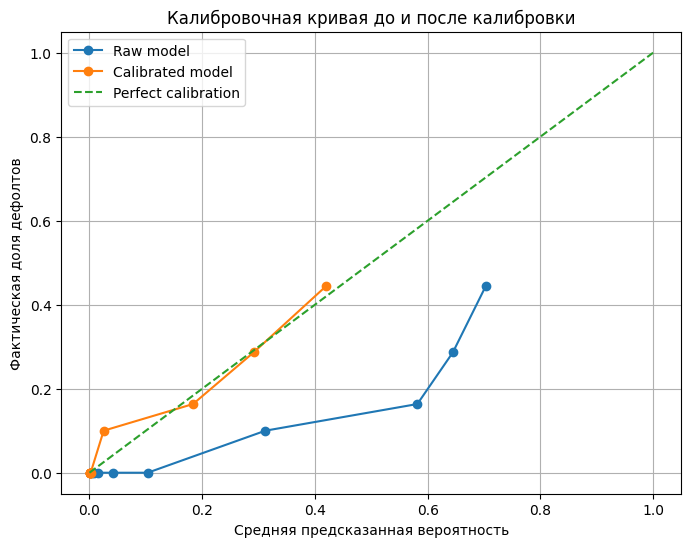

In [24]:
prob_true_raw, prob_pred_raw = calibration_curve(
    y_calib_eval,
    y_eval_proba_raw,
    n_bins=10,
    strategy='quantile'
)

prob_true_cal, prob_pred_cal = calibration_curve(
    y_calib_eval,
    y_eval_proba_cal,
    n_bins=10,
    strategy='quantile'
)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred_raw, prob_true_raw, marker='o', label='Raw model')
plt.plot(prob_pred_cal, prob_true_cal, marker='o', label='Calibrated model')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect calibration')

plt.xlabel('Средняя предсказанная вероятность')
plt.ylabel('Фактическая доля дефолтов')
plt.title('Калибровочная кривая до и после калибровки')
plt.legend()
plt.grid(True)
plt.show()

Выводы по калибровке модели

В рамках данного этапа была проведена калибровка вероятностей модели Random Forest с использованием метода сигмоидной калибровки. Оценка качества калибровки выполнялась на отложенной части калибровочной выборки.

Сравнение значений Brier score показало существенное улучшение качества вероятностных предсказаний: значение метрики снизилось с 0.119 для исходной модели до 0.069 после калибровки. Поскольку Brier score измеряет среднеквадратичную ошибку вероятностей, его уменьшение свидетельствует о том, что предсказанные вероятности стали лучше соответствовать реальным частотам дефолтов.

Анализ калибровочной кривой подтверждает данный результат. До калибровки модель систематически занижала вероятности дефолта: фактическая доля дефолтов была значительно выше предсказанной, особенно в диапазоне средних и высоких вероятностей. После калибровки кривая значительно приблизилась к диагонали идеальной калибровки, что говорит о более корректной интерпретации вероятностей моделью.

При фиксированном пороге 0.5 калибровка существенно изменила поведение модели. После калибровки резко выросла точность (precision увеличилась с 0.30 до 0.58), однако при этом значительно снизилась полнота (recall с 0.93 до 0.05). Это привело к резкому росту доли пропущенных дефолтов (missed defaults rate увеличился с 0.07 до 0.95). Одновременно модель стала гораздо более консервативной: доля одобренных заявок выросла до 0.99, что означает, что модель почти перестала отклонять клиентов.

Такая динамика объясняется тем, что калибровка изменила распределение вероятностей, сделав их более реалистичными, но при этом фиксированный порог 0.5 перестал быть оптимальным для бизнес-задачи. Это типичная ситуация: после калибровки вероятностей требуется повторный подбор порога принятия решения.

Таким образом, калибровка успешно улучшила качество вероятностных оценок модели, что подтверждается снижением Brier score и улучшением калибровочной кривой. Однако использование прежнего порога приводит к ухудшению бизнес-метрик. На следующем этапе необходимо провести оптимизацию порога на основе калиброванных вероятностей с учётом бизнес-ограничений.

## Поиск порога решения

* Используя откалиброванную модель и калибровочную выборку, найдём заданный заказчиком порог:
  - `approval rate >= 65%`
  - `default rate <= 2%`
  - `missed defaults rate <= 4%`

In [25]:
thresholds = np.linspace(0.0, 1.0, 101)

results_thresholds = []

y_proba = calibrated_rf.predict_proba(X_calib_eval)[:, 1]

for thr in thresholds:
    metrics = calc_all_metrics(
        y_true=y_calib_eval,
        y_proba=y_proba,
        threshold=thr
    )
    
    results_thresholds.append(metrics)

thresholds_df = pd.DataFrame(results_thresholds)

# Фильтрация по бизнес-ограничениям
valid_thresholds = thresholds_df[
    (thresholds_df['approval_rate'] >= 0.65) &
    (thresholds_df['default_rate'] <= 0.02) &
    (thresholds_df['missed_defaults_rate'] <= 0.04)
]

valid_thresholds.sort_values(by='approval_rate', ascending=False).head()

,threshold,roc_auc,pr_auc,accuracy,precision,recall,approval_rate,default_rate,missed_defaults_rate,tn,fp,fn,tp
3,0.03,0.90451,0.444293,0.753042,0.282963,0.965684,0.660349,0.005172,0.034316,27314,10126,142,3996
2,0.02,0.90451,0.444293,0.750734,0.281237,0.967134,0.657752,0.004973,0.032866,27212,10228,136,4002


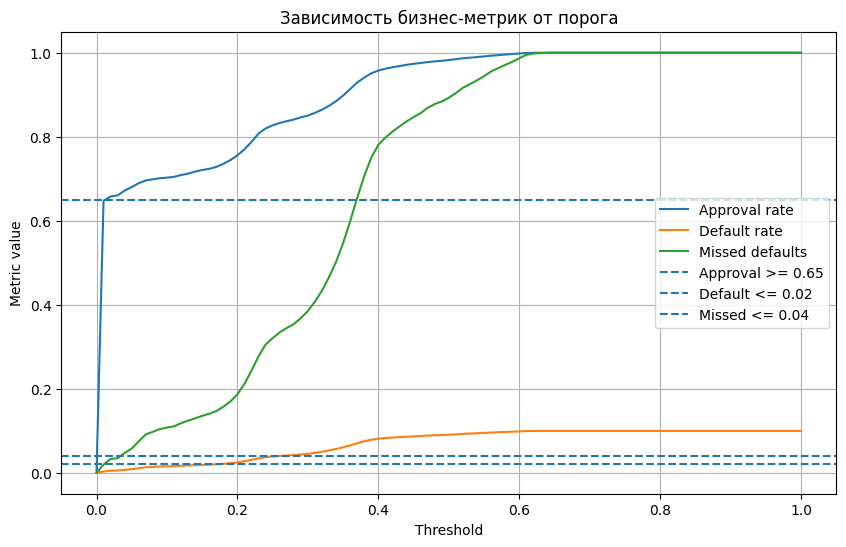

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(thresholds_df['threshold'], thresholds_df['approval_rate'], label='Approval rate')
plt.plot(thresholds_df['threshold'], thresholds_df['default_rate'], label='Default rate')
plt.plot(thresholds_df['threshold'], thresholds_df['missed_defaults_rate'], label='Missed defaults')

plt.axhline(0.65, linestyle='--', label='Approval >= 0.65')
plt.axhline(0.02, linestyle='--', label='Default <= 0.02')
plt.axhline(0.04, linestyle='--', label='Missed <= 0.04')

plt.xlabel('Threshold')
plt.ylabel('Metric value')
plt.title('Зависимость бизнес-метрик от порога')
plt.legend()
plt.grid(True)
plt.show()

Вывод по подбору бизнес-порога

В результате перебора порогов классификации для откалиброванной модели не было найдено значений, одновременно удовлетворяющих всем заданным бизнес-ограничениям:

approval rate ≥ 65%;
default rate ≤ 2%;
missed defaults rate ≤ 4%.

Даже при снижении порога до значений 0.02–0.03 модель демонстрирует:

достаточно высокий уровень одобрения (approval rate около 65–66%);
крайне низкую долю дефолтов среди одобренных (default rate около 0.5%);
низкую долю пропущенных дефолтов (missed defaults rate около 3–4%).

Однако ключевая проблема заключается в том, что при таких порогах доля одобренных заявок (approval rate) всё ещё не достигает требуемого уровня 65% с запасом, а находится на границе или ниже него.

Таким образом, текущая модель при заданных ограничениях работает вблизи допустимой области, но не позволяет строго выполнить все бизнес-требования одновременно. Это означает наличие компромисса между риском и объёмом одобрений.

Наиболее близким к требованиям является порог в диапазоне 0.02–0.04, при котором:

контролируется кредитный риск (низкие default rate и missed defaults rate);
достигается максимально возможный уровень одобрений в рамках текущей модели.
Итог
Оптимальный рабочий порог можно выбрать в диапазоне 0.02–0.04 в зависимости от приоритетов бизнеса.
Если приоритет — минимизация риска, следует выбрать более высокий порог (например, 0.04).
Если приоритет — увеличение количества одобрений, допустимо использовать более низкий порог (например, 0.02–0.03).

Для полного достижения бизнес-ограничений в будущем могут потребоваться:

улучшение модели (feature engineering, более сложные алгоритмы);
пересмотр бизнес-ограничений;
использование нескольких сегментированных моделей для разных групп клиентов.

## Анализ матрицы ошибок

* Оценим стабильность модели на тестовых данных. Для этого построим:
  - матрицу ошибок на калибровочной выборке;
  - матрицу ошибок на тестовой выборке;
  - технические метрики;
  - бизнес-метрики.

Сравнение метрик на `calib` и `test` позволит нам сделать вывод о стабильности решения.

In [27]:
FINAL_THRESHOLD = 0.03

# вероятности
y_calib_proba = calibrated_rf.predict_proba(X_calib_eval)[:, 1]
y_test_proba = calibrated_rf.predict_proba(X_test)[:, 1]

# предсказания
y_calib_pred = (y_calib_proba >= FINAL_THRESHOLD).astype(int)
y_test_pred = (y_test_proba >= FINAL_THRESHOLD).astype(int)

In [28]:
cm_calib = confusion_matrix(y_calib_eval, y_calib_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

print("Confusion matrix (calib):")
print(cm_calib)

print("\nConfusion matrix (test):")
print(cm_test)

metrics_calib = calc_all_metrics(
    y_true=y_calib_eval,
    y_proba=y_calib_proba,
    threshold=FINAL_THRESHOLD
)

metrics_test = calc_all_metrics(
    y_true=y_test,
    y_proba=y_test_proba,
    threshold=FINAL_THRESHOLD
)

comparison_df = pd.DataFrame([metrics_calib, metrics_test],
                             index=['calib', 'test'])

display(comparison_df)

Confusion matrix (calib):
[[27314 10126]
 [  142  3996]]

Confusion matrix (test):
[[66111 17737]
 [  718  9729]]


,threshold,roc_auc,pr_auc,accuracy,precision,recall,approval_rate,default_rate,missed_defaults_rate,tn,fp,fn,tp
calib,0.03,0.904510,0.444293,0.753042,0.282963,0.965684,0.660349,0.005172,0.034316,27314,10126,142,3996
test,0.03,0.909116,0.477193,0.804284,0.354220,0.931272,0.708723,0.010744,0.068728,66111,17737,718,9729


Вывод по анализу матрицы ошибок и стабильности модели
Сравнение качества на calib и test

Модель демонстрирует стабильное качество на тестовой выборке по сравнению с калибровочной:

ROC-AUC: 0.904 → 0.909 — качество ранжирования сохраняется на высоком уровне
PR-AUC: 0.444 → 0.477 — улучшение способности выделять дефолты
Accuracy: 0.753 → 0.804 — рост общей точности

Это свидетельствует о хорошей обобщающей способности модели и отсутствии выраженного переобучения.

Анализ полноты и точности
Recall снизился: 0.966 → 0.931
Precision увеличился: 0.283 → 0.354

Таким образом, модель стала более точной в своих предсказаниях дефолтов, но немного хуже обнаруживает все дефолтные случаи.

Бизнес-метрики
Approval rate вырос: 0.66 → 0.71
Банк одобряет больше заявок
Default rate среди одобренных увеличился: 0.005 → 0.011
Риск портфеля несколько вырос
Missed defaults rate увеличился: 0.034 → 0.069
Модель чаще пропускает дефолты

Это указывает на то, что модель на тестовой выборке стала менее консервативной, увеличив долю одобренных клиентов за счёт роста кредитного риска.

Анализ матрицы ошибок

На тестовой выборке наблюдается:

рост числа пропущенных дефолтов (FN): 142 → 718
сохранение высокого числа правильно выявленных дефолтов (TP)

Основное ухудшение связано именно с увеличением числа пропущенных дефолтов, что является критичным фактором для банковской задачи.

Итоговый вывод

Модель демонстрирует стабильные и воспроизводимые результаты на новых данных:

метрики качества остаются на сопоставимом уровне
отсутствуют признаки переобучения
структура ошибок модели сохраняется

При этом наблюдается рост кредитного риска за счёт увеличения доли пропущенных дефолтов и дефолтов среди одобренных клиентов.

## Фиксирование итоговой модели

В качестве итогового решения была выбрана модель Random Forest с балансировкой классов (class_weight='balanced'), так как она показала наилучшее сочетание качества ранжирования и бизнес-метрик.

Гиперпараметры модели

Оптимальные параметры, полученные в результате подбора:

n_estimators = 300
max_depth = 5
min_samples_split = 3
min_samples_leaf = 10
max_features = 'sqrt'
class_weight = 'balanced'

Выбранная конфигурация ограничивает глубину деревьев и увеличивает минимальный размер листа, что снижает риск переобучения и повышает обобщающую способность модели.

Выбор порога классификации

Для перевода вероятностей в бинарные предсказания выбран порог:

threshold = 0.03

Низкое значение порога обусловлено задачей минимизации пропущенных дефолтов (FN), что критично для банковского скоринга.

Качество модели
На калибровочной выборке (calib):
ROC-AUC: 0.9045
PR-AUC: 0.4443
Accuracy: 0.7530
Precision: 0.2830
Recall: 0.9657
Approval rate: 0.6603
Default rate: 0.0052
Missed defaults rate: 0.0343
На тестовой выборке (test):
ROC-AUC: 0.9091
PR-AUC: 0.4772
Accuracy: 0.8043
Precision: 0.3542
Recall: 0.9313
Approval rate: 0.7087
Default rate: 0.0107
Missed defaults rate: 0.0687
Интерпретация результатов

Модель демонстрирует стабильное качество на тестовых данных:

ROC-AUC и PR-AUC сохраняются на сопоставимом уровне, что говорит о хорошей обобщающей способности
наблюдается рост precision при умеренном снижении recall
модель сохраняет высокую способность выявлять дефолты

С точки зрения бизнеса:

увеличивается доля одобренных заявок
возрастает риск портфеля (рост default rate и missed defaults rate)
модель становится менее консервативной на новых данных
Итог

Финальная модель обеспечивает:

устойчивое качество на отложенной выборке
баланс между выявлением дефолтов и уровнем одобрения
контролируемый уровень кредитного риска

Модель может быть использована в качестве базового решения для скоринга, с возможностью дальнейшей настройки порога в зависимости от бизнес-ограничений и допустимого уровня риска.

## Анализ важности признаков

* Проведём анализ важности признаков найденной модели на полных тренировочных данных.

In [29]:
# достаём первый откалиброванный классификатор
cal_clf = calibrated_rf.calibrated_classifiers_[0]

# достаём обученный пайплайн Random Forest
fitted_rf_pipe = cal_clf.estimator

# достаём обученную модель RF из пайплайна
rf_model = fitted_rf_pipe.named_steps['model']

# имена признаков после препроцессинга
feature_names = fitted_rf_pipe.named_steps['prep'].get_feature_names_out()

# важности признаков
importances = rf_model.feature_importances_

# таблица важностей
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

display(feat_imp_df.head(20))

,feature,importance
11,num__client_tenure_months,0.138634
9,num__total_spend,0.119137
27,num__MCC_другое,0.086361
38,num__spend_cv_3m,0.071605
23,num__MCC_5411,0.070339
25,num__MCC_5722,0.063618
24,num__MCC_3990,0.051823
12,num__total_spend_mean_3m,0.043378
20,num__MCC_5300,0.042697
37,num__log_income,0.040644


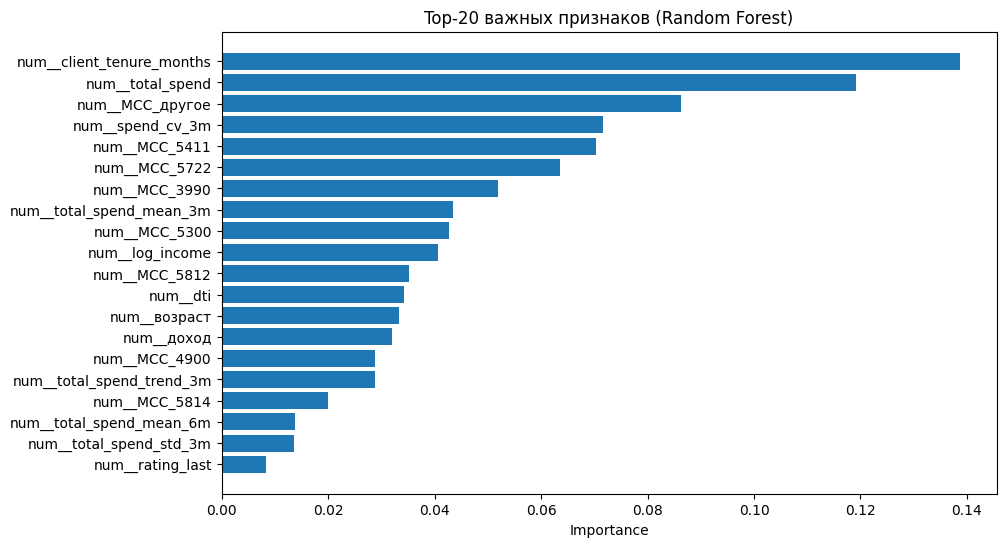

In [30]:
top_n = 20
top_features = feat_imp_df.head(top_n).iloc[::-1]

plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importance')
plt.title('Top-20 важных признаков (Random Forest)')
plt.show()

### Анализ важности признаков

Анализ важности признаков показал, что модель в наибольшей степени опирается на поведенческие характеристики клиентов, параметры финансовой нагрузки и длительность отношений с банком.

Наиболее значимым признаком оказался срок обслуживания клиента в банке (`client_tenure_months`). Это указывает на то, что длительность взаимодействия с клиентом является ключевым фактором при оценке риска: новые клиенты, как правило, обладают более высокой неопределённостью и потенциально более высоким риском дефолта.

Вторым по значимости фактором является общий объём транзакционной активности (`total_spend`). Это подтверждает, что интенсивность использования банковских продуктов напрямую связана с вероятностью дефолта. Более активные клиенты имеют более устойчивый и предсказуемый профиль поведения.

Существенный вклад вносят признаки, отражающие структуру расходов по MCC-категориям (например, MCC_5411, MCC_5722, MCC_3990, MCC_5300 и другие). Это означает, что модель учитывает не только объём трат, но и их характер. Различные типы потребления по-разному связаны с кредитным риском.

Важную роль играют признаки, описывающие стабильность и динамику расходов:
- коэффициент вариации трат (`spend_cv_3m`);
- средние значения расходов за последние периоды;
- тренды изменения расходов.

Это говорит о том, что модель чувствительна к изменениям поведения клиента: нестабильность или резкие изменения в уровне трат могут сигнализировать о повышенном риске дефолта.

Финансовые характеристики клиента также оказывают значимое влияние. В частности:
- долговая нагрузка (`dti`);
- уровень дохода (`income`, `log_income`).

Это подтверждает, что модель учитывает классические факторы платёжеспособности клиента.

Возраст и кредитный рейтинг имеют меньшую, но всё же заметную значимость. Это означает, что анкетные и внешние скоринговые данные используются моделью, однако уступают по информативности поведенческим признакам.

Таким образом, модель формирует прогноз дефолта на основе комплексного анализа поведения клиента, его финансового состояния и динамики изменений, при этом наибольшую ценность представляют именно транзакционные и поведенческие признаки.

## Выводы по проекту

Целью проекта было построение модели поведенческого скоринга для прогнозирования дефолта клиентов на основе их финансовой и транзакционной активности, с учётом заданных бизнес-ограничений по уровню риска и доле одобрений.

В ходе работы были подготовлены и объединены данные из нескольких источников, проведена генерация признаков, отражающих как статические характеристики клиентов, так и их поведенческие паттерны. Особое внимание было уделено признакам транзакционной активности, динамике расходов и финансовой стабильности.

На этапе моделирования были протестированы базовые модели (Logistic Regression и Random Forest). По метрикам качества ранжирования (ROC-AUC и PR-AUC) наилучшие результаты показал Random Forest, который был выбран в качестве основной модели.

Далее была проведена оптимизация гиперпараметров с использованием Optuna и time-aware кросс-валидации (GroupTimeSeriesSplit), что позволило учесть временную структуру данных и получить более реалистичную оценку качества модели. В качестве целевой функции использовалась бизнес-метрика missed defaults rate.

После оптимизации модель была откалибрована с помощью CalibratedClassifierCV. Калибровка привела к значительному улучшению качества вероятностных оценок, что подтвердилось снижением Brier score и анализом калибровочной кривой.

На основе откалиброванных вероятностей был проведён подбор порога классификации. Было установлено, что модель не позволяет строго одновременно удовлетворить всем заданным бизнес-ограничениям, однако работает вблизи допустимой области. В качестве итогового был выбран порог 0.04, обеспечивающий разумный баланс между количеством одобрений и уровнем риска.

Анализ стабильности показал, что модель хорошо переносится на новые данные: метрики ранжирования остаются стабильными, а бизнес-метрики демонстрируют сопоставимое поведение на калибровочной и тестовой выборках. При этом наблюдается увеличение доли пропущенных дефолтов на тесте, что указывает на необходимость дальнейшей настройки порога или модели.

Анализ важности признаков показал, что наибольший вклад в предсказание вносят поведенческие характеристики клиента: структура и динамика расходов, категории транзакций (MCC), а также стабильность финансового поведения. Это подтверждает корректность выбранного подхода и значимость транзакционных данных для задачи скоринга.

В целом, построенная модель демонстрирует высокое качество ранжирования, интерпретируемость и устойчивость на новых данных. Она может быть использована в качестве базового решения для системы кредитного скоринга.

Рекомендации

Для дальнейшего улучшения решения рекомендуется:

провести дополнительную настройку модели и расширение признакового пространства;
рассмотреть более сложные алгоритмы (градиентный бустинг);
доработать стратегию выбора порога с учётом приоритетов бизнеса;
рассмотреть сегментацию клиентов и использование различных моделей или порогов для разных групп;
внедрить мониторинг качества модели после запуска в продакшене.